# Taxi Fare Prediction with a Generalized Additive Model (GAM)

This notebook predicts NYC taxi **fare amount** using only non-fare-related trip features by fitting a Generalized Additive Model (GAM). Features include trip distance, trip duration, hour of day, day of week, and passenger count — no fare-related columns (tips, tolls, surcharges, etc.) are used.

## 1. Configuration

In [1]:
# ── Configuration ──────────────────────────────────────────────────────────
# Path to a single .parquet file, a local directory, or an S3 prefix.
# For the class S3 bucket, use the full path to a specific yellow-taxi file.
DATA_PATH = "s3://dsc291-ucsd/taxi/Dataset/2023/yellow_taxi/yellow_tripdata_2023-01.parquet"
MAX_ROWS  = 200_000                   # set to None to use all rows
RANDOM_SEED = 42
TRAIN_FRAC  = 0.80                    # 80 % train, 20 % validation
AWS_REGION  = "us-west-2"             # region for the S3 bucket

## 2. Load and Prepare Data

In [2]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 40)

In [3]:
# ── Discover and load parquet ──────────────────────────────────────────────
import pyarrow.parquet as pq
import pyarrow.fs as pafs

path = DATA_PATH

if path.startswith("s3://"):
    # Build a pyarrow S3 filesystem (try credentials first, fall back to anonymous)
    try:
        s3 = pafs.S3FileSystem(region=AWS_REGION)
        # Quick check: will throw if creds are missing
        s3.get_file_info(path.replace("s3://", ""))
    except Exception:
        s3 = pafs.S3FileSystem(region=AWS_REGION, anonymous=True)

    s3_path = path.replace("s3://", "")
    info = s3.get_file_info(s3_path)

    if info.type.name == "File":
        # Single file
        print(f"Loading single S3 file: {path}")
        table = pq.read_table(s3_path, filesystem=s3)
        df = table.to_pandas()
    else:
        # Directory — discover yellow-taxi parquet files
        selector = pafs.FileSelector(s3_path, recursive=True)
        all_files = s3.get_file_info(selector)
        parquet_files = sorted([
            f.path for f in all_files
            if f.path.endswith(".parquet") and "yellow" in f.path.lower()
        ])
        print(f"Found {len(parquet_files)} yellow-taxi parquet files in S3")
        chosen = parquet_files[0]
        print(f"Loading: s3://{chosen}")
        table = pq.read_table(chosen, filesystem=s3)
        df = table.to_pandas()

elif os.path.isdir(path):
    parquet_files = sorted(glob.glob(os.path.join(path, "**/*.parquet"), recursive=True))
    if not parquet_files:
        raise FileNotFoundError(f"No parquet files found in {path}")
    print(f"Found {len(parquet_files)} parquet file(s) in directory")
    chosen = parquet_files[0]
    print(f"Loading: {chosen}")
    df = pd.read_parquet(chosen)
else:
    print(f"Loading single file: {path}")
    df = pd.read_parquet(path)

print(f"Raw rows loaded: {len(df):,}")
print(f"Columns: {list(df.columns)}")

Loading single S3 file: s3://dsc291-ucsd/taxi/Dataset/2023/yellow_taxi/yellow_tripdata_2023-01.parquet


Raw rows loaded: 3,066,766
Columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


In [4]:
# ── Optional subsample ─────────────────────────────────────────────────────
if MAX_ROWS is not None and len(df) > MAX_ROWS:
    df = df.sample(n=MAX_ROWS, random_state=RANDOM_SEED).reset_index(drop=True)
    print(f"Subsampled to {len(df):,} rows")
else:
    print(f"Using all {len(df):,} rows")

Subsampled to 200,000 rows


In [5]:
# ── Normalize column names ─────────────────────────────────────────────────
# Map common alternate names to a canonical set
COLUMN_MAP = {
    # pickup datetime
    "tpep_pickup_datetime":  "pickup_datetime",
    "trip_pickup_datetime":  "pickup_datetime",
    "pickup_datetime":       "pickup_datetime",
    # dropoff datetime
    "tpep_dropoff_datetime": "dropoff_datetime",
    "trip_dropoff_datetime": "dropoff_datetime",
    "dropoff_datetime":      "dropoff_datetime",
    # trip distance
    "trip_distance":         "trip_distance",
    "trip_miles":            "trip_distance",
    # passenger count
    "passenger_count":       "passenger_count",
    # fare amount
    "fare_amount":           "fare_amount",
    "fare_amt":              "fare_amount",
}

# Lowercase all columns for matching
df.columns = df.columns.str.lower().str.strip()
rename = {k: v for k, v in COLUMN_MAP.items() if k in df.columns}
df = df.rename(columns=rename)

required = ["pickup_datetime", "dropoff_datetime", "trip_distance",
            "passenger_count", "fare_amount"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise KeyError(f"Missing required columns after normalization: {missing}")

print("Columns after normalization:", list(df.columns))

Columns after normalization: ['vendorid', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'trip_distance', 'ratecodeid', 'store_and_fwd_flag', 'pulocationid', 'dolocationid', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


In [6]:
# ── Parse datetimes and derive features ────────────────────────────────────
df["pickup_datetime"]  = pd.to_datetime(df["pickup_datetime"], errors="coerce")
df["dropoff_datetime"] = pd.to_datetime(df["dropoff_datetime"], errors="coerce")

df["trip_duration_min"] = (
    (df["dropoff_datetime"] - df["pickup_datetime"]).dt.total_seconds() / 60.0
)
df["hour_of_day"] = df["pickup_datetime"].dt.hour
df["day_of_week"] = df["pickup_datetime"].dt.dayofweek  # 0=Mon … 6=Sun

print("Derived features: trip_duration_min, hour_of_day, day_of_week")
df[["trip_distance", "trip_duration_min", "hour_of_day", "day_of_week",
    "passenger_count", "fare_amount"]].describe().round(2)

Derived features: trip_duration_min, hour_of_day, day_of_week


,trip_distance,trip_duration_min,hour_of_day,day_of_week,passenger_count,fare_amount
count,200000.00,200000.00,200000.00,200000.00,195402.00,200000.00
mean,3.44,15.71,14.14,3.01,1.36,18.33
std,21.43,42.92,5.77,1.99,0.89,17.60
min,0.00,0.00,0.00,0.00,0.00,-231.90
25%,1.06,7.10,10.00,1.00,1.00,8.60
50%,1.80,11.52,15.00,3.00,1.00,12.80
75%,3.35,18.32,19.00,5.00,1.00,20.50
max,7729.75,2766.65,23.00,6.00,6.00,500.00


In [7]:
# ── Clean data ─────────────────────────────────────────────────────────────
n_before = len(df)

# Drop rows with missing or non-positive values
df = df.dropna(subset=["fare_amount", "trip_distance", "trip_duration_min",
                        "passenger_count", "hour_of_day", "day_of_week"])
df = df[(df["fare_amount"] > 0) &
        (df["trip_distance"] > 0) &
        (df["trip_duration_min"] > 0) &
        (df["passenger_count"] > 0)]

# Cap extreme values at the 99th percentile
for col in ["fare_amount", "trip_distance", "trip_duration_min"]:
    cap = df[col].quantile(0.99)
    n_capped = (df[col] > cap).sum()
    df[col] = df[col].clip(upper=cap)
    print(f"  {col}: capped {n_capped:,} rows at {cap:.2f}")

print(f"\nRows before cleaning: {n_before:,}")
print(f"Rows after  cleaning: {len(df):,}  (dropped {n_before - len(df):,})")

  fare_amount: capped 1,868 rows at 70.00
  trip_distance: capped 1,883 rows at 19.97
  trip_duration_min: capped 1,881 rows at 57.00

Rows before cleaning: 200,000
Rows after  cleaning: 188,226  (dropped 11,774)


In [8]:
# ── Train / validation split ───────────────────────────────────────────────
FEATURES = ["trip_distance", "trip_duration_min", "hour_of_day",
            "day_of_week", "passenger_count"]
TARGET = "fare_amount"

X = df[FEATURES].values
y = df[TARGET].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, train_size=TRAIN_FRAC, random_state=RANDOM_SEED
)

print(f"Train size: {X_train.shape[0]:,}")
print(f"Val   size: {X_val.shape[0]:,}")

Train size: 150,580
Val   size: 37,646


## 3. Define and Fit the GAM

In [9]:
from pygam import LinearGAM, s, l

# Compatibility workaround: pygam 0.12 may call .A on sparse matrices,
# which was removed in SciPy >= 1.14.  Patch if needed.
import scipy.sparse
if not hasattr(scipy.sparse.csr_matrix, "A"):
    scipy.sparse.csr_matrix.A = property(lambda self: self.toarray())
    print("Applied scipy sparse .A compatibility patch")

# Feature order: trip_distance(0), trip_duration_min(1), hour_of_day(2),
#                day_of_week(3), passenger_count(4)
# Smooth terms for distance, duration, hour, day_of_week;
# Linear term for passenger_count.
gam = LinearGAM(
    s(0, n_splines=20) +     # trip_distance
    s(1, n_splines=20) +     # trip_duration_min
    s(2, n_splines=12) +     # hour_of_day (0-23)
    s(3, n_splines=7)  +     # day_of_week (0-6)
    l(4)                      # passenger_count (linear)
)

# Fit with default lambda grid search
gam.gridsearch(X_train, y_train, progress=True)

print("\nGAM fit complete.")
print(f"  GCV score (lower is better): {gam.statistics_['GCV']:.4f}")

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--

Applied scipy sparse .A compatibility patch


  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:05

 18% (2 of 11) |####                     | Elapsed Time: 0:00:01 ETA:   0:00:04

 27% (3 of 11) |######                   | Elapsed Time: 0:00:01 ETA:   0:00:04

...

 72% (8 of 11) |##################       | Elapsed Time: 0:00:04 ETA:   0:00:01

 81% (9 of 11) |####################     | Elapsed Time: 0:00:04 ETA:   0:00:01

 90% (10 of 11) |#####################   | Elapsed Time: 0:00:05 ETA:   0:00:00

100% (11 of 11) |########################| Elapsed Time: 0:00:05 Time:  0:00:05


GAM fit complete.
  GCV score (lower is better): 7.2446


## 4. Evaluate

In [10]:
# ── Predict on validation set ──────────────────────────────────────────────
y_pred = gam.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae  = mean_absolute_error(y_val, y_pred)
r2   = r2_score(y_val, y_pred)

print(f"Validation RMSE : {rmse:.3f}")
print(f"Validation MAE  : {mae:.3f}")
print(f"Validation R²   : {r2:.4f}")

Validation RMSE : 2.738
Validation MAE  : 0.888
Validation R²   : 0.9691


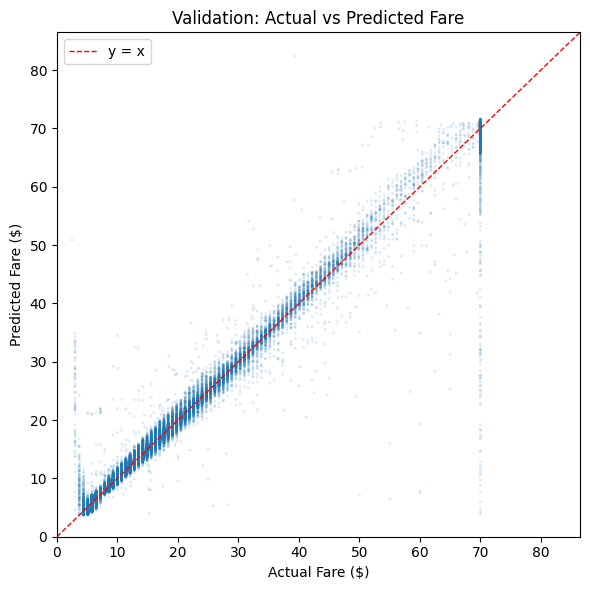

In [11]:
# ── Actual vs Predicted scatter plot ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_val, y_pred, alpha=0.15, s=4, edgecolors="none")
lims = [0, max(y_val.max(), y_pred.max()) * 1.05]
ax.plot(lims, lims, "r--", linewidth=1, label="y = x")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Actual Fare ($)")
ax.set_ylabel("Predicted Fare ($)")
ax.set_title("Validation: Actual vs Predicted Fare")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Interpret — Partial Dependence Plots

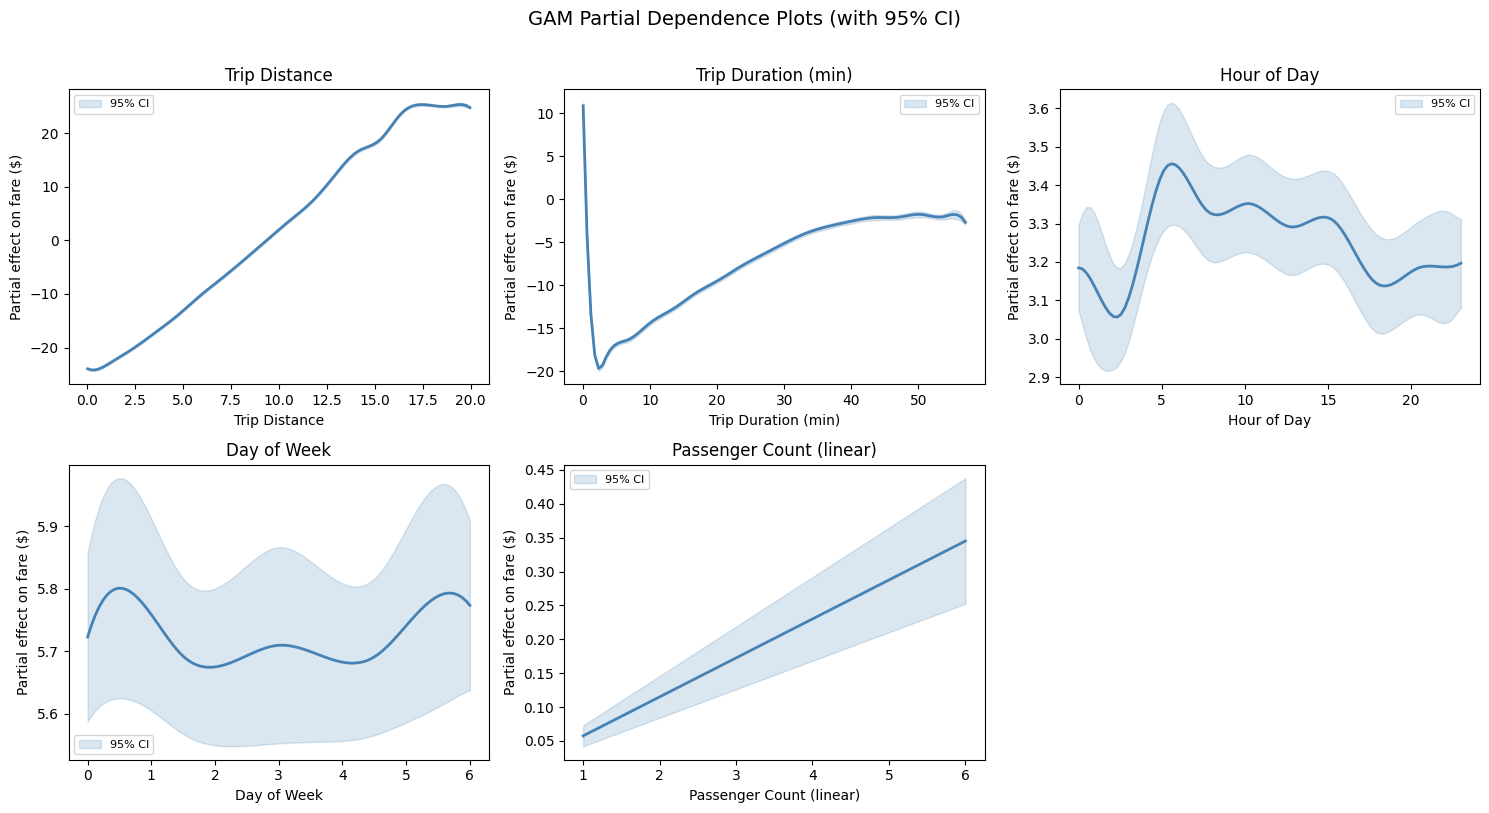

In [12]:
# ── Partial dependence (term effect) plots with confidence intervals ──────
term_names = ["Trip Distance", "Trip Duration (min)", "Hour of Day",
              "Day of Week", "Passenger Count (linear)"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (ax, name) in enumerate(zip(axes, term_names)):
    XX = gam.generate_X_grid(term=i)
    # Use per-term CI via partial_dependence(width=...) instead of
    # gam.confidence_intervals() which returns full-model CIs
    pdep, ci = gam.partial_dependence(term=i, X=XX, width=0.95)

    ax.plot(XX[:, i], pdep, color="steelblue", linewidth=2)
    ax.fill_between(
        XX[:, i],
        ci[:, 0],
        ci[:, 1],
        alpha=0.2, color="steelblue", label="95% CI"
    )
    ax.set_title(name)
    ax.set_xlabel(name)
    ax.set_ylabel("Partial effect on fare ($)")
    ax.legend(fontsize=8)

# Hide the unused subplot
axes[-1].set_visible(False)

fig.suptitle("GAM Partial Dependence Plots (with 95% CI)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Discussion — Limitations

The base model uses only trip distance, duration, time-of-day, day-of-week, and passenger count as predictors. It does **not** include tolls, surcharges, airport fees, or pickup/dropoff location, all of which contribute to the actual fare. As a result, the GAM cannot capture location-specific pricing (e.g., flat-rate airport fares) or toll-driven fare components, and its predictions will systematically under- or over-estimate fares for trips where those omitted factors are significant.

The extra-credit enhanced model adds pickup and dropoff location IDs as smooth terms, which partially addresses the location gap. The bootstrap analysis shows how the analytical confidence intervals from pyGAM compare to empirical resampling-based intervals — differences may arise because the analytical CIs assume the smoothing penalty is fixed while bootstrap CIs capture additional variability from penalty estimation.

## 7. Extra Credit — Enhanced GAM with Pickup/Dropoff Location

The base model omits location entirely. Here we add `PULocationID` and `DOLocationID` as
additional features (using smooth terms over the integer zone IDs) and compare the enhanced
model's performance against the baseline.

In [13]:
# ── Enhanced GAM with location features ────────────────────────────────────
# Check if location columns are available
loc_cols = [c for c in ["pulocationid", "dolocationid"] if c in df.columns]
if len(loc_cols) == 2:
    FEATURES_LOC = FEATURES + ["pulocationid", "dolocationid"]
    X_loc = df[FEATURES_LOC].values
    y_loc = df[TARGET].values

    X_loc_train, X_loc_val, y_loc_train, y_loc_val = train_test_split(
        X_loc, y_loc, train_size=TRAIN_FRAC, random_state=RANDOM_SEED
    )

    # Features: 0=distance, 1=duration, 2=hour, 3=dow, 4=passengers, 5=PU, 6=DO
    gam_loc = LinearGAM(
        s(0, n_splines=20) +    # trip_distance
        s(1, n_splines=20) +    # trip_duration_min
        s(2, n_splines=12) +    # hour_of_day
        s(3, n_splines=7)  +    # day_of_week
        l(4)               +    # passenger_count
        s(5, n_splines=25) +    # PULocationID
        s(6, n_splines=25)      # DOLocationID
    )

    gam_loc.gridsearch(X_loc_train, y_loc_train, progress=True)
    print("\nEnhanced GAM (with location) fit complete.")

    y_pred_loc = gam_loc.predict(X_loc_val)
    rmse_loc = np.sqrt(mean_squared_error(y_loc_val, y_pred_loc))
    mae_loc  = mean_absolute_error(y_loc_val, y_pred_loc)
    r2_loc   = r2_score(y_loc_val, y_pred_loc)

    print(f"\n{'Metric':<15} {'Base GAM':>10} {'+ Location':>10} {'Improvement':>12}")
    print("-" * 50)
    print(f"{'RMSE':<15} {rmse:>10.3f} {rmse_loc:>10.3f} {rmse - rmse_loc:>+11.3f}")
    print(f"{'MAE':<15} {mae:>10.3f} {mae_loc:>10.3f} {mae - mae_loc:>+11.3f}")
    print(f"{'R²':<15} {r2:>10.4f} {r2_loc:>10.4f} {r2_loc - r2:>+11.4f}")
else:
    print("Location columns not found — skipping enhanced model.")

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--

  9% (1 of 11) |##                       | Elapsed Time: 0:00:01 ETA:   0:00:10

 18% (2 of 11) |####                     | Elapsed Time: 0:00:02 ETA:   0:00:09

 27% (3 of 11) |######                   | Elapsed Time: 0:00:03 ETA:   0:00:08

 36% (4 of 11) |#########                | Elapsed Time: 0:00:04 ETA:   0:00:07

...

 72% (8 of 11) |##################       | Elapsed Time: 0:00:07 ETA:   0:00:02

 81% (9 of 11) |####################     | Elapsed Time: 0:00:08 ETA:   0:00:01

 90% (10 of 11) |#####################   | Elapsed Time: 0:00:09 ETA:   0:00:00

100% (11 of 11) |########################| Elapsed Time: 0:00:10 Time:  0:00:10


Enhanced GAM (with location) fit complete.

Metric            Base GAM + Location  Improvement
--------------------------------------------------
RMSE                 2.738      2.719      +0.019
MAE                  0.888      0.915      -0.026
R²                  0.9691     0.9695     +0.0004


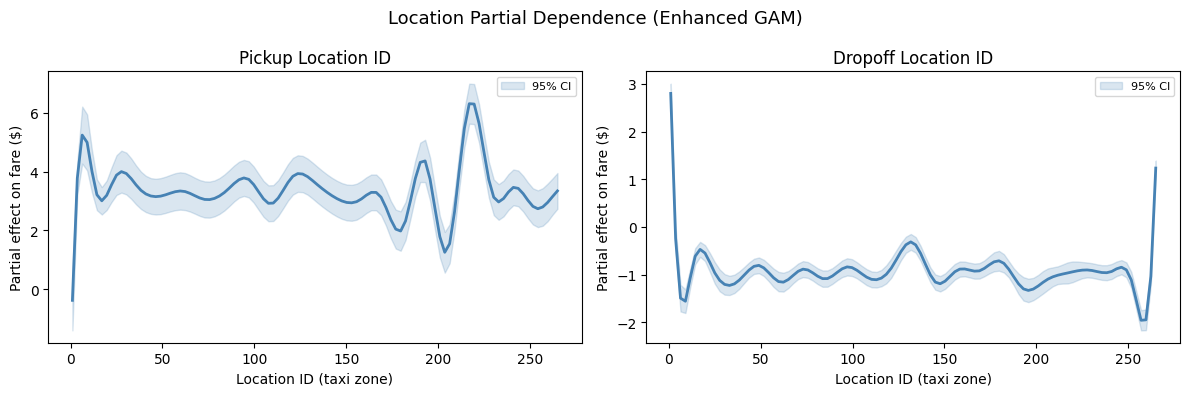

In [14]:
# ── Partial dependence for pickup and dropoff location ─────────────────────
if len(loc_cols) == 2:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, term_idx, name in zip(axes, [5, 6], ["Pickup Location ID", "Dropoff Location ID"]):
        XX = gam_loc.generate_X_grid(term=term_idx)
        # Use per-term CI instead of full-model confidence_intervals()
        pdep, ci = gam_loc.partial_dependence(term=term_idx, X=XX, width=0.95)
        ax.plot(XX[:, term_idx], pdep, color="steelblue", linewidth=2)
        ax.fill_between(XX[:, term_idx], ci[:, 0], ci[:, 1],
                        alpha=0.2, color="steelblue", label="95% CI")
        ax.set_title(name)
        ax.set_xlabel("Location ID (taxi zone)")
        ax.set_ylabel("Partial effect on fare ($)")
        ax.legend(fontsize=8)
    fig.suptitle("Location Partial Dependence (Enhanced GAM)", fontsize=13)
    plt.tight_layout()
    plt.show()

## 8. Extra Credit — Bootstrap vs pyGAM Confidence Intervals

pyGAM computes confidence intervals analytically from the posterior covariance of the spline
coefficients. Here we compare those against **bootstrap** confidence intervals: we resample the
training set B times, refit the GAM each time, and build pointwise percentile intervals for the
partial dependence curves of trip distance and trip duration.

In [15]:
# ── Bootstrap confidence intervals ─────────────────────────────────────────
B = 50  # number of bootstrap resamples
n_train = X_train.shape[0]
rng = np.random.RandomState(RANDOM_SEED)

# We'll collect bootstrap partial-dependence curves for terms 0 (distance) and 1 (duration)
terms_to_bootstrap = [0, 1, 2]  # distance, duration, hour
term_labels = ["Trip Distance", "Trip Duration (min)", "Hour of Day"]

# Pre-compute X grids from the original GAM
grids = {}
for t in terms_to_bootstrap:
    grids[t] = gam.generate_X_grid(term=t)

# Collect bootstrap partial dependence curves
boot_pdeps = {t: [] for t in terms_to_bootstrap}

print(f"Running {B} bootstrap resamples...")
for b in range(B):
    idx = rng.choice(n_train, size=n_train, replace=True)
    X_boot, y_boot = X_train[idx], y_train[idx]

    gam_boot = LinearGAM(
        s(0, n_splines=20) + s(1, n_splines=20) + s(2, n_splines=12) +
        s(3, n_splines=7) + l(4)
    )
    # Use the same lambda as the original fit for speed (skip grid search)
    gam_boot.fit(X_boot, y_boot)

    for t in terms_to_bootstrap:
        pdep_b = gam_boot.partial_dependence(term=t, X=grids[t])
        boot_pdeps[t].append(pdep_b)

    if (b + 1) % 10 == 0:
        print(f"  {b + 1}/{B} done")

# Convert to arrays
for t in terms_to_bootstrap:
    boot_pdeps[t] = np.array(boot_pdeps[t])  # shape (B, n_grid_points)

print("Bootstrap complete.")

Running 50 bootstrap resamples...


  10/50 done


  20/50 done


  30/50 done


  40/50 done


  50/50 done
Bootstrap complete.


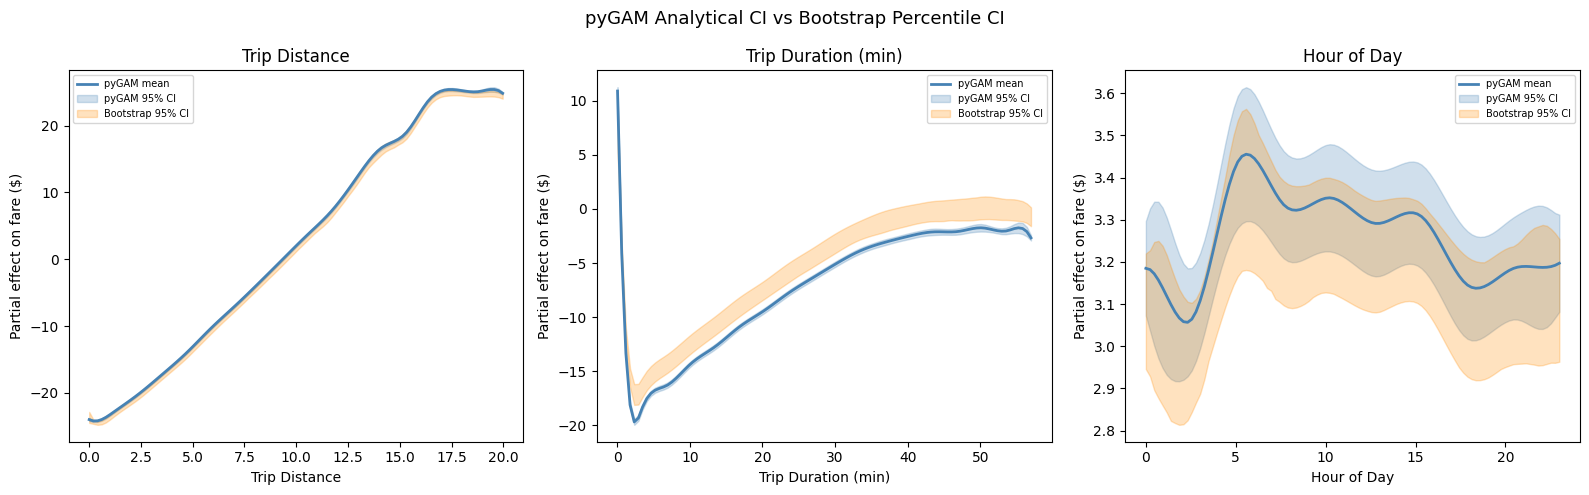


Term                       pyGAM CI width   Boot CI width    Ratio
------------------------------------------------------------------
Trip Distance                       0.411           0.824    0.50x
Trip Duration (min)                 0.531           1.849    0.29x
Hour of Day                         0.262           0.290    0.90x


In [16]:
# ── Compare pyGAM CI vs Bootstrap CI ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, t, label in zip(axes, terms_to_bootstrap, term_labels):
    XX = grids[t]
    x_vals = XX[:, t]

    # pyGAM per-term analytical CI (not full-model CI)
    pdep, ci_pygam = gam.partial_dependence(term=t, X=XX, width=0.95)

    # Bootstrap percentile CI
    boot_lo = np.percentile(boot_pdeps[t], 2.5, axis=0)
    boot_hi = np.percentile(boot_pdeps[t], 97.5, axis=0)

    ax.plot(x_vals, pdep, "steelblue", linewidth=2, label="pyGAM mean")
    ax.fill_between(x_vals, ci_pygam[:, 0], ci_pygam[:, 1],
                    alpha=0.25, color="steelblue", label="pyGAM 95% CI")
    ax.fill_between(x_vals, boot_lo, boot_hi,
                    alpha=0.25, color="darkorange", label="Bootstrap 95% CI")
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel("Partial effect on fare ($)")
    ax.legend(fontsize=7)

fig.suptitle("pyGAM Analytical CI vs Bootstrap Percentile CI", fontsize=13)
plt.tight_layout()
plt.show()

# ── Quantitative comparison: mean CI width ────────────────────────────────
print(f"\n{'Term':<25} {'pyGAM CI width':>15} {'Boot CI width':>15} {'Ratio':>8}")
print("-" * 66)
for t, label in zip(terms_to_bootstrap, term_labels):
    XX = grids[t]
    _, ci_pygam = gam.partial_dependence(term=t, X=XX, width=0.95)
    pygam_width = (ci_pygam[:, 1] - ci_pygam[:, 0]).mean()
    boot_lo = np.percentile(boot_pdeps[t], 2.5, axis=0)
    boot_hi = np.percentile(boot_pdeps[t], 97.5, axis=0)
    boot_width = (boot_hi - boot_lo).mean()
    print(f"{label:<25} {pygam_width:>15.3f} {boot_width:>15.3f} {pygam_width / boot_width:>7.2f}x")

## 9. Extra Credit — Predicting Breakdown of Cost

The total taxi fare is composed of several components: base fare, tips, tolls, extras, congestion
surcharge, and airport fee. Here we fit a separate GAM for each non-trivial cost component using
the same trip features, then visualize how each component contributes to the total predicted cost
across different trip distances. This reveals which components are predictable from trip features
and which are essentially noise.

In [17]:
# ── Predict fare breakdown by component ────────────────────────────────────
from pygam import LinearGAM, s, l

COST_COMPONENTS = {
    "fare_amount": "Base Fare",
    "tip_amount": "Tip",
    "tolls_amount": "Tolls",
    "extra": "Extra Charges",
    "congestion_surcharge": "Congestion Surcharge",
    "airport_fee": "Airport Fee",
}

available = {col: label for col, label in COST_COMPONENTS.items() if col in df.columns}
print(f"Modeling {len(available)} fare components: {list(available.values())}\n")

# Re-split using same seed to get matching indices for component columns
X_df = df[FEATURES]
idx_train, idx_val = train_test_split(
    df.index, train_size=TRAIN_FRAC, random_state=RANDOM_SEED
)

component_models = {}
component_metrics = []

for col, label in available.items():
    y_comp_train = df.loc[idx_train, col].values.astype(float)
    y_comp_val = df.loc[idx_val, col].values.astype(float)

    mask_train = np.isfinite(y_comp_train)
    mask_val = np.isfinite(y_comp_val)

    if mask_train.sum() < 100 or mask_val.sum() < 50:
        print(f"  {label:25s}  skipped (too few valid values)")
        continue

    gam_comp = LinearGAM(
        s(0) + s(1) + s(2) + s(3) + l(4),
        fit_intercept=True
    )
    gam_comp.fit(X_train[mask_train], y_comp_train[mask_train])

    pred_val = gam_comp.predict(X_val[mask_val])
    actual_val = y_comp_val[mask_val]

    rmse_c = np.sqrt(mean_squared_error(actual_val, pred_val))
    mae_c = mean_absolute_error(actual_val, pred_val)
    r2_c = r2_score(actual_val, pred_val)

    component_models[col] = gam_comp
    component_metrics.append({
        "Component": label,
        "Mean": f"${np.mean(y_comp_train):.2f}",
        "RMSE": f"${rmse_c:.3f}",
        "MAE": f"${mae_c:.3f}",
        "R²": f"{r2_c:.4f}",
    })
    print(f"  {label:25s}  mean=${np.mean(y_comp_train):6.2f}  RMSE=${rmse_c:.3f}  MAE=${mae_c:.3f}  R²={r2_c:.4f}")

print("\n── Component Model Performance ──")
metrics_df = pd.DataFrame(component_metrics)
display(metrics_df)

Modeling 6 fare components: ['Base Fare', 'Tip', 'Tolls', 'Extra Charges', 'Congestion Surcharge', 'Airport Fee']



  Base Fare                  mean=$ 18.26  RMSE=$2.726  MAE=$0.869  R²=0.9693


  Tip                        mean=$  3.40  RMSE=$2.967  MAE=$1.934  R²=0.3763


  Tolls                      mean=$  0.52  RMSE=$1.400  MAE=$0.484  R²=0.5064


  Extra Charges              mean=$  1.57  RMSE=$1.456  MAE=$1.110  R²=0.3255


  Congestion Surcharge       mean=$  2.32  RMSE=$0.584  MAE=$0.283  R²=0.1879


  Airport Fee                mean=$  0.11  RMSE=$0.240  MAE=$0.109  R²=0.5446

── Component Model Performance ──


,Component,Mean,RMSE,MAE,R²
0,Base Fare,$18.26,$2.726,$0.869,0.9693
1,Tip,$3.40,$2.967,$1.934,0.3763
2,Tolls,$0.52,$1.400,$0.484,0.5064
3,Extra Charges,$1.57,$1.456,$1.110,0.3255
4,Congestion Surcharge,$2.32,$0.584,$0.283,0.1879
5,Airport Fee,$0.11,$0.240,$0.109,0.5446


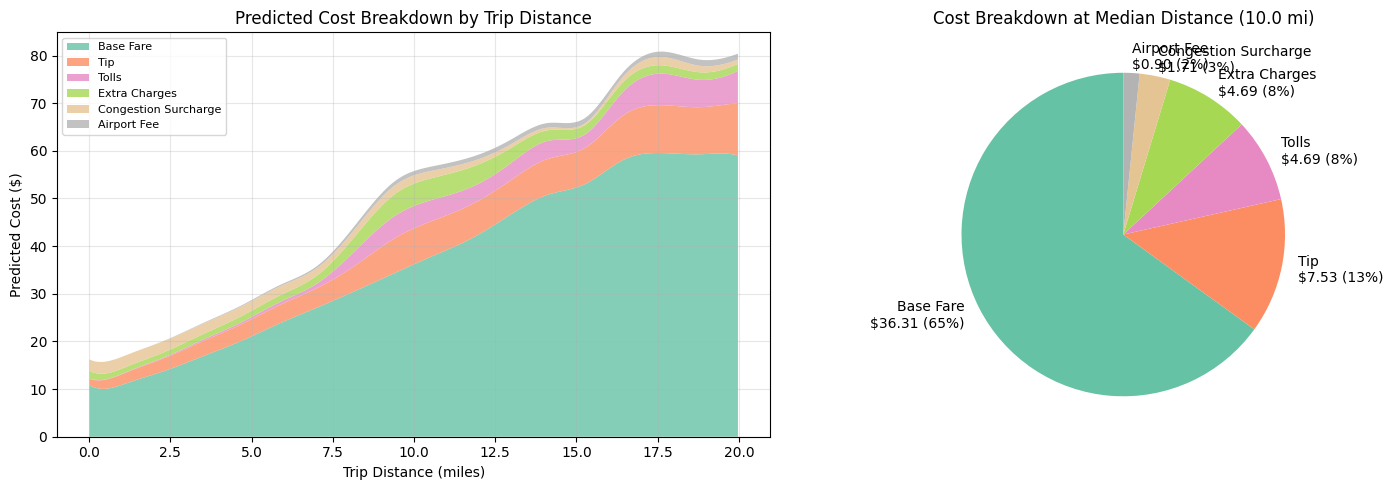

Saved cost_breakdown.png


In [18]:
# ── Stacked area: predicted cost breakdown vs trip distance ────────────────
distance_grid = np.linspace(X_val[:, 0].min(), X_val[:, 0].max(), 200)

# Build a reference X: median of all features, varying distance
median_features = np.median(X_train, axis=0)
XX_dist = np.tile(median_features, (len(distance_grid), 1))
XX_dist[:, 0] = distance_grid

# Predict each component across the distance grid
predictions = {}
for col, label in available.items():
    if col in component_models:
        predictions[label] = np.clip(component_models[col].predict(XX_dist), 0, None)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Stacked area plot
labels_sorted = list(predictions.keys())
values_sorted = np.array([predictions[l] for l in labels_sorted])
colors = plt.cm.Set2(np.linspace(0, 1, len(labels_sorted)))
ax1.stackplot(distance_grid, values_sorted, labels=labels_sorted, colors=colors, alpha=0.8)
ax1.set_xlabel("Trip Distance (miles)")
ax1.set_ylabel("Predicted Cost ($)")
ax1.set_title("Predicted Cost Breakdown by Trip Distance")
ax1.legend(loc="upper left", fontsize=8)
ax1.grid(True, alpha=0.3)

# Pie chart: average contribution at median distance
mid_idx = len(distance_grid) // 2
slices = [predictions[l][mid_idx] for l in labels_sorted]
slices_pos = [max(s, 0) for s in slices]
total = sum(slices_pos)
pct_labels = [f"{l}\n${s:.2f} ({100*s/total:.0f}%)" for l, s in zip(labels_sorted, slices_pos)]
ax2.pie(slices_pos, labels=pct_labels, colors=colors, autopct="", startangle=90)
ax2.set_title(f"Cost Breakdown at Median Distance ({distance_grid[mid_idx]:.1f} mi)")

plt.tight_layout()
plt.savefig("cost_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved cost_breakdown.png")